In [124]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 200)
X = pd.read_csv('nfl_team_stats_2002-2024.csv')
X = X[X['season'] >=2005].copy()
X['home'] = X['home'].astype(str)
X['away'] = X['away'].astype(str)
X['home_win'] = X['score_home'] > X['score_away']
X['home_win'] = X['home_win'].astype(int)
#if you tie at home means the other team "won" as they dont have home field advantage
X


,season,week,date,time_et,neutral,away,home,score_away,score_home,first_downs_away,...,redzone_att_home,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home,home_win
801,2005,1,2005-09-08,9:00 PM,False,Raiders,Patriots,20,30,19,...,5,1,0,0,0,0,0,27:40,32:20,1
802,2005,1,2005-09-11,1:00 PM,False,Texans,Bills,7,22,12,...,4,2,0,3,0,0,0,21:45,38:15,1
803,2005,1,2005-09-11,1:00 PM,False,Bengals,Browns,27,13,26,...,3,1,1,1,2,0,0,34:13,25:47,0
804,2005,1,2005-09-11,1:00 PM,False,Jets,Chiefs,7,27,19,...,5,2,0,1,1,0,0,31:29,28:31,1
805,2005,1,2005-09-11,1:00 PM,False,Broncos,Dolphins,10,34,19,...,4,1,2,2,1,0,2,27:42,32:18,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6209,2024,Division,2025-01-19,3:00 PM,False,Rams,Eagles,22,28,18,...,2,2,0,0,0,0,0,29:06,30:54,1
6210,2024,Division,2025-01-19,6:30 PM,False,Ravens,Bills,25,27,23,...,4,2,0,1,0,0,0,28:16,31:44,1
6211,2024,Conference,2025-01-26,3:00 PM,False,Commanders,Eagles,23,55,22,...,7,3,0,1,0,0,0,29:29,30:31,1
6212,2024,Conference,2025-01-26,6:30 PM,False,Bills,Chiefs,29,32,22,...,6,0,1,0,0,0,0,30:32,29:28,1


In [125]:
def poss_to_seconds(val):
    try:
        m, s = map(int, val.split(':'))
        return m * 60 + s
    except:
        return np.nan
    
X.loc[:, 'possession_home'] = X['possession_home'].apply(poss_to_seconds)
X.loc[:, 'possession_away'] = X['possession_away'].apply(poss_to_seconds)
X.loc[:,'week'] = pd.to_numeric(X['week'], errors='coerce')
X = X.dropna(subset=['week'])
X= X.copy()


X.loc[:,'game_id'] = X.index




In [126]:
home_cols = [col for col in X.columns if col.endswith('_home')]
away_cols = [col for col in X.columns if col.endswith('_away')]

home_df = X[['season', 'week', 'game_id', 'home', 'home_win'] + home_cols].copy()
away_df = X[['season', 'week', 'game_id', 'away'] + away_cols].copy()

home_df = home_df.rename(columns=lambda x: x.replace('_home', '') if x.endswith('_home') else x)
away_df = away_df.rename(columns=lambda x: x.replace('_away', '') if x.endswith('_away') else x)

home_df = home_df.rename(columns={'home': 'team'})
away_df = away_df.rename(columns={'away': 'team'})


In [127]:
long_X = pd.concat([home_df, away_df], ignore_index=True)
long_X = long_X.sort_values(by =['season', 'team', 'week'])
#print(long_X.head(200))

stat_cols = [col for col in long_X.columns if col not in ['season', 'week', 'team', 'game_id', 'home_win']]
print(stat_cols)


rolling_avg = (
    long_X
    .groupby(['season', 'team'])[stat_cols]
    .transform(lambda x: x.shift(1).expanding().mean())
)
print(rolling_avg)

long_X = long_X.sort_values(by=['season', 'team', 'week'])
rolling_X = pd.concat([long_X[['season', 'week', 'team', 'game_id', 'home_win']], rolling_avg], axis=1)
print(rolling_X.head(30))

home_stats = rolling_X.merge(X[['game_id', 'home']], left_on=['game_id', 'team'], right_on=['game_id', 'home'])
away_stats = rolling_X.merge(X[['game_id', 'away']], left_on=['game_id', 'team'], right_on=['game_id', 'away'])

home_stats = home_stats.add_suffix('_home')
away_stats = away_stats.add_suffix('_away')

final_X = pd.merge(home_stats, away_stats, left_on='game_id_home', right_on='game_id_away')
final_X = final_X.rename(columns={'game_id_home': 'game_id'}).drop(columns=['game_id_away'])

final_X = final_X[final_X['week_home'] > 1].copy()



['score', 'first_downs', 'first_downs_from_passing', 'first_downs_from_rushing', 'first_downs_from_penalty', 'third_down_comp', 'third_down_att', 'fourth_down_comp', 'fourth_down_att', 'plays', 'drives', 'yards', 'pass_comp', 'pass_att', 'pass_yards', 'sacks_num', 'sacks_yards', 'rush_att', 'rush_yards', 'pen_num', 'pen_yards', 'redzone_comp', 'redzone_att', 'fumbles', 'interceptions', 'def_st_td', 'possession']
           score  first_downs  first_downs_from_passing  \
10           NaN          NaN                       NaN   
5201   28.000000    12.000000                 10.000000   
41     15.500000    10.000000                  8.500000   
5241   20.666667    13.000000                  9.333333   
68     19.000000    11.750000                  8.750000   
...          ...          ...                       ...   
5108   24.750000    20.583333                 11.833333   
5133   26.076923    20.769231                 12.076923   
10328  26.357143    21.000000                 12.2142

In [128]:
final_X['week'] = final_X['week_home']
final_X['week'] = final_X['week_home']
final_X['season'] = final_X['season_home']
final_X['home_win'] = final_X['home_win_home']
final_X = final_X.drop(['season_home', 'week_home', 'home_home', 'season_away', 'week_away', 'away_away', 'home_win_home', 'home_win_away'], axis =1)

print(final_X.columns)
final_X.head(30)

Index(['team_home', 'game_id', 'score_home', 'first_downs_home',
       'first_downs_from_passing_home', 'first_downs_from_rushing_home',
       'first_downs_from_penalty_home', 'third_down_comp_home',
       'third_down_att_home', 'fourth_down_comp_home', 'fourth_down_att_home',
       'plays_home', 'drives_home', 'yards_home', 'pass_comp_home',
       'pass_att_home', 'pass_yards_home', 'sacks_num_home',
       'sacks_yards_home', 'rush_att_home', 'rush_yards_home', 'pen_num_home',
       'pen_yards_home', 'redzone_comp_home', 'redzone_att_home',
       'fumbles_home', 'interceptions_home', 'def_st_td_home',
       'possession_home', 'team_away', 'score_away', 'first_downs_away',
       'first_downs_from_passing_away', 'first_downs_from_rushing_away',
       'first_downs_from_penalty_away', 'third_down_comp_away',
       'third_down_att_away', 'fourth_down_comp_away', 'fourth_down_att_away',
       'plays_away', 'drives_away', 'yards_away', 'pass_comp_away',
       'pass_att_away', '

,team_home,game_id,score_home,first_downs_home,first_downs_from_passing_home,first_downs_from_rushing_home,first_downs_from_penalty_home,third_down_comp_home,third_down_att_home,fourth_down_comp_home,...,pen_yards_away,redzone_comp_away,redzone_att_away,fumbles_away,interceptions_away,def_st_td_away,possession_away,week,season,home_win
1,49ers,842,15.500000,10.000000,8.500000,1.000000,0.500000,2.000000,9.500000,0.000000,...,53.000000,0.0,3.000000,0.500000,0.000000,0.000000,1898.000000,3.0,2005,0.0
2,49ers,869,19.000000,11.750000,8.750000,2.500000,0.500000,3.500000,10.750000,0.000000,...,28.750000,0.0,2.500000,0.000000,0.500000,0.500000,1698.750000,5.0,2005,0.0
3,49ers,913,16.000000,11.333333,7.000000,3.166667,1.166667,3.333333,11.500000,0.166667,...,84.666667,0.0,2.500000,0.333333,1.166667,0.333333,2041.833333,8.0,2005,1.0
4,49ers,925,15.857143,11.000000,6.142857,3.714286,1.142857,3.142857,12.142857,0.142857,...,66.857143,0.0,4.428571,0.857143,0.714286,0.285714,1702.142857,9.0,2005,0.0
5,49ers,955,14.000000,10.555556,5.111111,3.888889,1.555556,3.000000,12.777778,0.222222,...,57.333333,0.0,4.111111,0.555556,0.777778,0.000000,1784.111111,11.0,2005,0.0
6,49ers,988,15.727273,11.545455,6.181818,3.909091,1.454545,3.181818,13.000000,0.454545,...,71.727273,0.0,2.909091,0.909091,1.272727,0.363636,1836.272727,13.0,2005,0.0
7,49ers,1052,14.600000,11.466667,5.933333,4.066667,1.466667,2.800000,12.333333,0.333333,...,52.000000,0.0,2.266667,0.733333,0.733333,0.133333,1727.333333,17.0,2005,1.0
8,Bears,823,7.000000,11.000000,9.000000,2.000000,0.000000,6.000000,13.000000,0.000000,...,38.000000,0.0,3.000000,0.000000,0.000000,0.000000,1736.000000,2.0,2005,1.0
9,Bears,840,22.500000,14.500000,7.000000,7.500000,0.000000,7.000000,14.000000,0.000000,...,77.500000,0.0,6.000000,0.500000,1.000000,0.000000,2186.500000,3.0,2005,0.0
10,Bears,882,15.500000,15.250000,7.500000,7.000000,0.750000,5.500000,14.000000,0.500000,...,65.750000,0.0,2.750000,1.250000,2.500000,0.500000,1745.500000,6.0,2005,1.0


In [129]:
y = final_X['home_win']
X = final_X.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])


train = final_X[final_X['season'] < 2024]
test = final_X[final_X['season'] == 2024]

X_train = train.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])
y_train = train['home_win']
X_test = test.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])
y_test = test['home_win']


In [130]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.6015625
ROC AUC: 0.5981159774896012


                          feature  importance
27                     score_away    0.030145
0                      score_home    0.026790
38                     yards_away    0.020906
22               redzone_att_home    0.020873
11                     yards_home    0.020768
16               sacks_yards_home    0.020400
24             interceptions_home    0.020112
30  first_downs_from_rushing_away    0.019479
47                 pen_yards_away    0.019458
49               redzone_att_away    0.019287
35           fourth_down_att_away    0.019286
15                 sacks_num_home    0.019188
18                rush_yards_home    0.018996
5            third_down_comp_home    0.018779
48              redzone_comp_away    0.018755
51             interceptions_away    0.018731
28               first_downs_away    0.018696
37                    drives_away    0.018659
42                 sacks_num_away    0.018571
17                  rush_att_home    0.018141


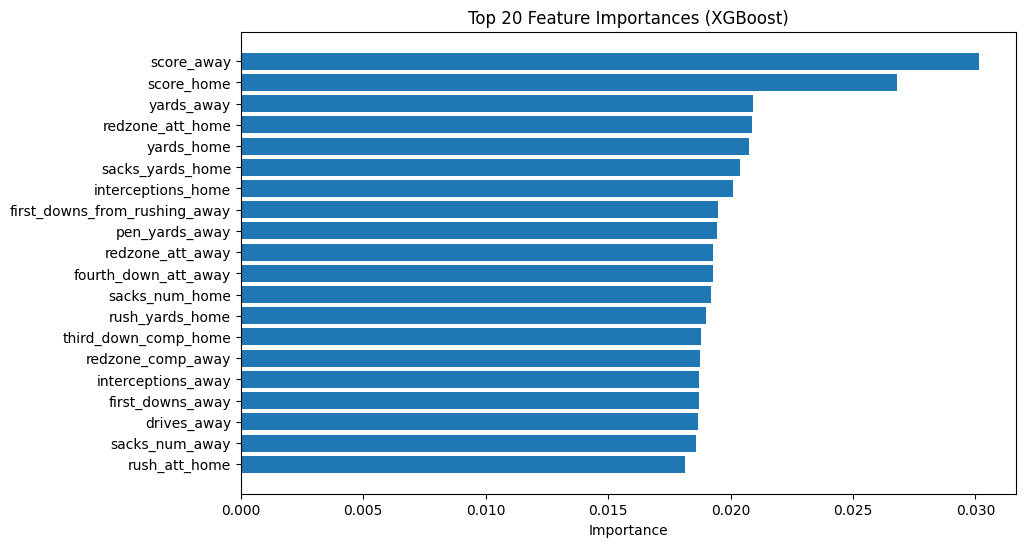

In [131]:
feature_names = X_train.columns


importances = model.feature_importances_

feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

In [132]:
home_cols = [c for c in final_X.columns if c.endswith("_home")]
away_cols = [c for c in final_X.columns if c.endswith("_away")]
home_cols.remove('team_home')
away_cols.remove('team_away')

home_cols = sorted(home_cols)
away_cols = sorted(away_cols)

for h, a in zip(home_cols, away_cols):
    base = h.replace("_home", "")
    diff_col = f"{base}_diff"
    final_X[diff_col] = X[h] - X[a]

# Keep only diffs + target + identifiers you want
diff_cols = [c for c in final_X.columns if c.endswith("_diff")]
X2 = final_X[diff_cols + ['week', 'season', 'home_win']]


train = X2[X2['season'] < 2023]
test = X2[X2['season'] > 2023]

X_train = train.drop(columns=['home_win', 'week'])
y_train = train['home_win']
X_test = test.drop(columns=['home_win', 'week'])
y_test = test['home_win']


In [133]:
model2 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model2.fit(X_train, y_train)

# Evaluate
y_pred_proba = model2.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.63671875
ROC AUC: 0.6324321017861512


                          feature  importance
23                     score_diff    0.065195
26                     yards_diff    0.040494
21                 sacks_num_diff    0.039512
22               sacks_yards_diff    0.037558
9              interceptions_diff    0.037466
5                first_downs_diff    0.036169
2   first_downs_from_passing_diff    0.036078
13                   pen_num_diff    0.035856
16                possession_diff    0.035538
6            fourth_down_att_diff    0.035191
11                 pass_comp_diff    0.034897
10                  pass_att_diff    0.034748
24            third_down_att_diff    0.034421
25           third_down_comp_diff    0.034370
8                    fumbles_diff    0.034370
3   first_downs_from_penalty_diff    0.034334
12                pass_yards_diff    0.033948
17               redzone_att_diff    0.033451
15                     plays_diff    0.033370
4   first_downs_from_rushing_diff    0.033267


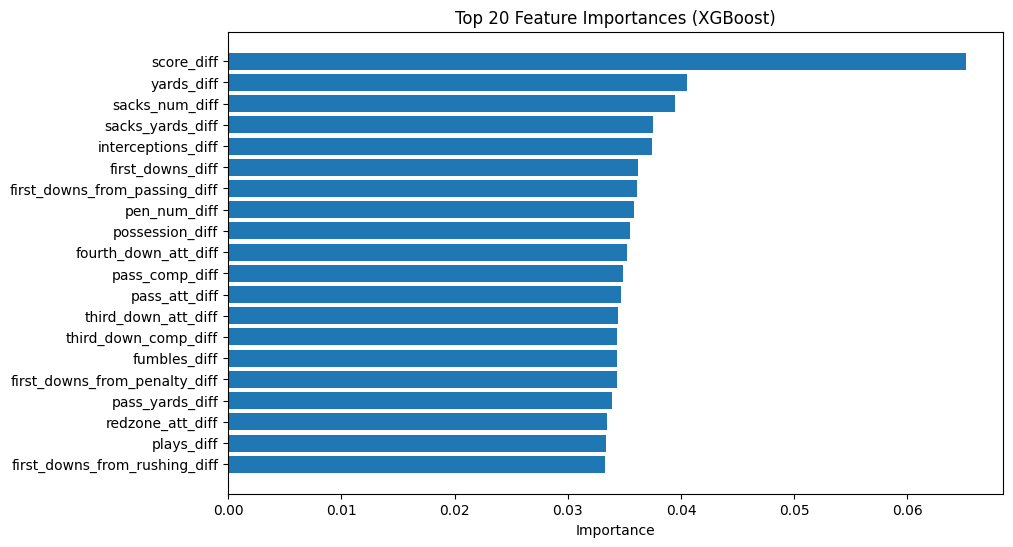

In [134]:
feature_names = X_train.columns


importances = model2.feature_importances_

feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

In [166]:
model3 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

week = 1
currCols = ['score_diff', 'yards_diff', 'redzone_att_diff', 'possession_diff', 'sacks_yards_diff', 'first_downs_diff', 'fumbles_diff', 'rush_yards_diff']

model3.fit(X_train[currCols], y_train)

X_test_Week_Lim = test.drop(columns=['home_win'])
X_test_Week_Lim = X_test_Week_Lim[X_test_Week_Lim['week']>week]

y_test_Week_Lim = test[test['week']>week]['home_win']

# Evaluate
y_pred_proba = model3.predict_proba(X_test_Week_Lim[currCols])[:,1]
print(y_pred_proba)
y_pred = (y_pred_proba > 0.51).astype(int)

print()

print("Accuracy:", accuracy_score(y_test_Week_Lim, y_pred))
print("ROC AUC:", roc_auc_score(y_test_Week_Lim, y_pred))

[0.41344967 0.6202798  0.5960476  0.80311704 0.61488646 0.58695376
 0.5949474  0.47612834 0.32925612 0.6187109  0.6648164  0.6109262
 0.15888776 0.4110357  0.4380062  0.23073432 0.12798305 0.5748003
 0.6672826  0.64086884 0.357054   0.8485166  0.512735   0.58424914
 0.9310642  0.8604723  0.9175297  0.84592146 0.96823645 0.90290403
 0.62235755 0.37955153 0.24489747 0.69331473 0.3665022  0.77866465
 0.48831835 0.65575224 0.6368055  0.5317559  0.4542086  0.35044014
 0.25122747 0.5049361  0.4447967  0.48763883 0.1827502  0.28668362
 0.6435529  0.537596   0.7091825  0.46539736 0.86467624 0.42239928
 0.3249475  0.77135485 0.35187623 0.530472   0.7316234  0.7296575
 0.7706709  0.6153764  0.24909994 0.16787785 0.45226374 0.48859072
 0.54722106 0.12141623 0.5665363  0.58063227 0.0750729  0.48521677
 0.6997022  0.82721263 0.44835523 0.56222767 0.8985689  0.7645395
 0.8483021  0.18246382 0.15548255 0.6660626  0.84146345 0.60508955
 0.945413   0.89023983 0.9116836  0.8215436  0.8986307  0.8754844


In [66]:
final_X.to_csv('final_nfl_rolling_stats.csv', index=False)
